Dataset shape: (6, 10000)


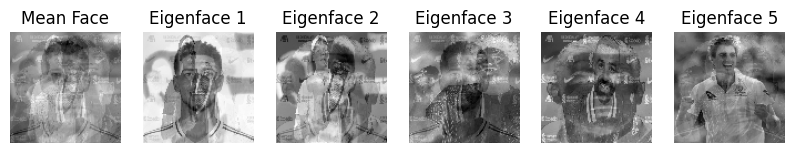

Feature vector shape: (6, 6)
Example feature vector for first image: [-0.57793512 -1.04365422  0.80086527  1.43669505 -0.19484787  0.91287093]


In [2]:
import cv2
import numpy as np
import os
from sklearn.decomposition import PCA
from matplotlib import pyplot as plt

# -----------------------------
# 1️⃣ Load Images and Flatten
# -----------------------------
dataset_path = "../dataset/test/"  # প্রতিটি ফোল্ডারে আলাদা ব্যক্তির ছবি
images = []
labels = []

label_dict = {}
current_label = 0

for person_name in os.listdir(dataset_path):
    person_path = os.path.join(dataset_path, person_name)
    if not os.path.isdir(person_path):
        continue
    label_dict[current_label] = person_name
    for img_name in os.listdir(person_path):
        img_path = os.path.join(person_path, img_name)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)  # grayscale
        img = cv2.resize(img, (100, 100))  # uniform size
        img_flat = img.flatten()
        images.append(img_flat)
        labels.append(current_label)
    current_label += 1

images = np.array(images)
labels = np.array(labels)

print("Dataset shape:", images.shape)  # (num_images, 10000)

# -----------------------------
# 2️⃣ Compute Mean Face & PCA
# -----------------------------
pca = PCA(n_components=min(10, images.shape[0]), whiten=True)
pca_features = pca.fit_transform(images)

mean_face = pca.mean_.reshape(100, 100)
eigenfaces = pca.components_.reshape(-1, 100, 100)

# -----------------------------
# 3️⃣ Visualize Mean Face & Eigenfaces
# -----------------------------
plt.figure(figsize=(10, 4))

# Mean face
plt.subplot(1, 6, 1)
plt.imshow(mean_face, cmap='gray')
plt.title("Mean Face")
plt.axis('off')

# Top 5 eigenfaces
for i in range(5):
    plt.subplot(1, 6, i+2)
    plt.imshow(eigenfaces[i], cmap='gray')
    plt.title(f"Eigenface {i+1}")
    plt.axis('off')

plt.show()

# -----------------------------
# 4️⃣ PCA Feature Vectors
# -----------------------------
print("Feature vector shape:", pca_features.shape)
print("Example feature vector for first image:", pca_features[0])